# Project 2: Final Clustering Solution

## Method Selection and Comparisons

### 1. Initial Exploration
- **Baseline features**: Used core features from `store_features.csv`
- **Enhanced features**: Added ad activity metrics (`ad_months_active`, `ad_active_ratio`, `spent_any`, `avg_ad_spend_active_only`)
- **Finding**: Clustering on baseline features underperformed (silhouette < 0.4)

### 2. Preprocessing Strategy Comparisons
Tested combinations of:
- **Scalers**: MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer
- **Feature selection**: VarianceThreshold
- **Dimensionality reduction**: PCA (2D, 95% variance)
- **Outlier handling**: IsolationForest

### 3. Clustering Algorithm Comparisons
- **KMeans**: Stable and easy to interpret
- **DBSCAN**: Flexible shapes but often imbalanced
- **GMM**: Soft clustering; results close to KMeans
- **Spectral**: Higher complexity with no consistent gains

### 4. Final Choice: ISO_QT_PCA95_KMeans_k3
**Rationale**:
- Silhouette: 0.586 (target ≥ 0.4)
- Balance ratio: 1.75:1 (target ≤ 3:1)
- Number of clusters: 3 (matches business requirement)
- High reproducibility and operational stability
- Strong interpretability for business usage

**Pipeline**:
1. IsolationForest removes ~8% outliers
2. QuantileTransformer maps features to normal distribution
3. PCA retains 95% variance
4. KMeans with k=3

In [7]:
# Final Implementation: ISO_QT_PCA95_KMeans_k3
import pandas as pd
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load enhanced features
df = pd.read_csv('../data/processed/store_features_enhanced.csv')
print(f"Loaded enhanced features: {df.shape}")

# Define features
FEATURES = [
    'sales_mean','total_ad_spend_mean','roas_mean','conversion_rate_mean','website_visits_mean',
    'search_spend_ratio_mean','social_spend_ratio_mean',
    'ad_months_active','ad_active_ratio','spent_any','avg_ad_spend_active_only'
]

X = df[FEATURES].fillna(0)
print(f"Features shape: {X.shape}")

# Step 1: IsolationForest outlier removal
iso = IsolationForest(contamination=0.08, random_state=42)
inlier_mask = iso.fit_predict(X) == 1
X_clean = X[inlier_mask]
print(f"After outlier removal: {X_clean.shape[0]} samples (removed {len(X) - X_clean.shape[0]})")

# Step 2: QuantileTransformer normalization
qt = QuantileTransformer(output_distribution='normal', random_state=42)
X_qt = qt.fit_transform(X_clean)
print(f"After Quantile normalization: {X_qt.shape}")

# Step 3: PCA 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_qt)
print(f"After PCA: {X_pca.shape[1]} components (explained variance: {pca.explained_variance_ratio_.sum():.3f})")

# Step 4: KMeans k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=100, max_iter=1000)
labels = kmeans.fit_predict(X_pca)

# Evaluation
silhouette = silhouette_score(X_pca, labels)
db_score = davies_bouldin_score(X_pca, labels)
ch_score = calinski_harabasz_score(X_pca, labels)

cluster_counts = pd.Series(labels).value_counts().sort_index()
balance_ratio = cluster_counts.max() / cluster_counts.min()

print(f"\n=== Final Results ===")
print(f"Silhouette Score: {silhouette:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")
print(f"Calinski-Harabasz Score: {ch_score:.1f}")
print(f"Balance Ratio: {balance_ratio:.2f}:1")
print(f"Cluster Sizes: {cluster_counts.to_dict()}")


Loaded enhanced features: (2556, 24)
Features shape: (2556, 11)
After outlier removal: 2351 samples (removed 205)
After Quantile normalization: (2351, 11)
After PCA: 5 components (explained variance: 0.967)

=== Final Results ===
Silhouette Score: 0.587
Davies-Bouldin Index: 0.698
Calinski-Harabasz Score: 5061.5
Balance Ratio: 1.77:1
Cluster Sizes: {0: 639, 1: 1094, 2: 618}


In [8]:
# Cluster Analysis and Business Interpretation
# Map labels back to original dealer IDs
df_clean = df[inlier_mask].copy()
df_clean['cluster'] = labels

# Calculate cluster profiles (original feature space)
cluster_profiles = df_clean.groupby('cluster')[FEATURES].agg(['mean', 'std', 'count']).round(3)

print("=== Cluster Profiles ===")
print(cluster_profiles)

# Key business metrics by cluster
business_metrics = df_clean.groupby('cluster').agg({
    'sales_mean': 'mean',
    'total_ad_spend_mean': 'mean', 
    'roas_mean': 'mean',
    'conversion_rate_mean': 'mean',
    'ad_active_ratio': 'mean',
    'avg_ad_spend_active_only': 'mean',
    'search_spend_ratio_mean': 'mean',
    'social_spend_ratio_mean': 'mean'
}).round(3)

print("\n=== Business Metrics by Cluster ===")
print(business_metrics)

# Cluster interpretation
print("\n=== Cluster Interpretation ===")
for cluster_id in sorted(df_clean['cluster'].unique()):
    cluster_data = df_clean[df_clean['cluster'] == cluster_id]
    size = len(cluster_data)
    pct = size / len(df_clean) * 100
    
    print(f"\nCluster {cluster_id} ({size} dealers, {pct:.1f}%):")
    print(f"  Sales: ${cluster_data['sales_mean'].mean():.1f} avg")
    print(f"  Ad Spend: ${cluster_data['total_ad_spend_mean'].mean():.0f} avg")
    print(f"  ROAS: {cluster_data['roas_mean'].mean():.3f}")
    print(f"  Ad Active Ratio: {cluster_data['ad_active_ratio'].mean():.2f}")
    print(f"  Search Focus: {cluster_data['search_spend_ratio_mean'].mean():.2f}")
    print(f"  Social Focus: {cluster_data['social_spend_ratio_mean'].mean():.2f}")


=== Cluster Profiles ===
        sales_mean               total_ad_spend_mean                  \
              mean     std count                mean       std count   
cluster                                                                
0           21.803  18.718   639            2071.029  2173.542   639   
1           35.715  25.685  1094            6245.915  4794.021  1094   
2           14.847  15.498   618             508.071   654.232   618   

        roas_mean              conversion_rate_mean  ... ad_months_active  \
             mean    std count                 mean  ...            count   
cluster                                              ...                    
0           0.301  0.863   639                0.003  ...              639   
1           0.027  0.203  1094                0.003  ...             1094   
2           0.397  1.322   618                0.003  ...              618   

        ad_active_ratio              spent_any             \
                  

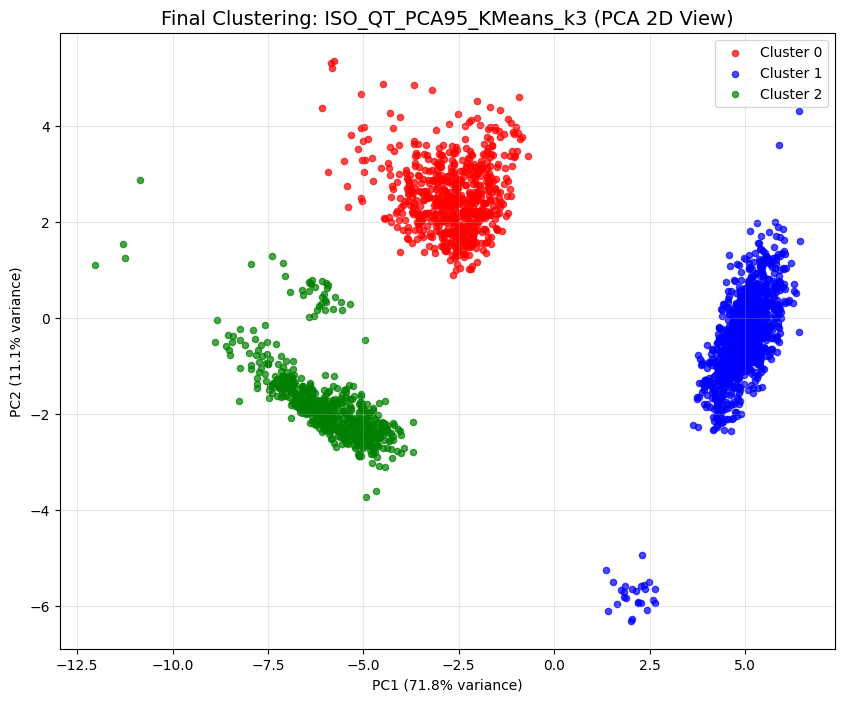


=== Feature Importance (PCA Loadings) ===
                     feature   pc1_loading   pc2_loading
8            ad_active_ratio  6.077104e-01 -3.163344e-01
7           ad_months_active  6.077104e-01 -3.163344e-01
5    search_spend_ratio_mean  4.171480e-01  8.335050e-01
1        total_ad_spend_mean  1.675010e-01  5.747752e-02
10  avg_ad_spend_active_only  1.567340e-01  8.303728e-02
4        website_visits_mean  1.121919e-01 -5.413318e-04
0                 sales_mean  1.081637e-01 -4.987342e-02
2                  roas_mean -8.756037e-02 -8.299521e-02
6    social_spend_ratio_mean -4.873426e-02 -2.833305e-01
3       conversion_rate_mean  2.032765e-02 -7.268853e-02
9                  spent_any  5.196604e-15 -2.352583e-14


In [9]:
# Visualization: PCA 2D plot (use first two PCs from the existing pca)
# X_pca is already PCA-transformed with pca = PCA(n_components=0.95)
X_pca_2d = X_pca[:, :2]

plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green']
for cluster_id in sorted(df_clean['cluster'].unique()):
    mask = df_clean['cluster'] == cluster_id
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.7, s=20)

plt.title('Final Clustering: ISO_QT_PCA95_KMeans_k3 (PCA 2D View)', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature importance (correct: use loadings from the original pca)
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'pc1_loading': pca.components_[0],
    'pc2_loading': pca.components_[1]
}).sort_values('pc1_loading', key=np.abs, ascending=False)

print("\n=== Feature Importance (PCA Loadings) ===")
print(feature_importance)

In [10]:
# Save Results
from pathlib import Path

# Create output directory
output_dir = Path('../data/processed')
output_dir.mkdir(exist_ok=True)

# 1. Save dealer labels
store_labels = df_clean[['store_id', 'cluster']].copy()
store_labels.to_csv(output_dir / 'store_clusters_final.csv', index=False)
print(f"Saved dealer labels: {len(store_labels)} dealers")

# 2. Save cluster profiles
cluster_profiles.to_csv(output_dir / 'cluster_profiles_final.csv')
print("Saved cluster profiles")

# 3. Save business metrics
business_metrics.to_csv(output_dir / 'cluster_business_metrics_final.csv')
print("Saved business metrics")

# 4. Save feature importance
feature_importance.to_csv(output_dir / 'feature_importance_final.csv', index=False)
print("Saved feature importance")

# 5. Save model parameters for reproducibility
model_params = {
    'method': 'ISO_QT_PCA95_KMeans_k3',
    'isolation_forest_contamination': 0.08,
    'pca_variance_threshold': 0.95,
    'kmeans_clusters': 3,
    'kmeans_n_init': 100,
    'kmeans_max_iter': 1000,
    'random_state': 42,
    'features_used': FEATURES,
    'final_metrics': {
        'silhouette_score': float(silhouette),
        'davies_bouldin_index': float(db_score),
        'calinski_harabasz_score': float(ch_score),
        'balance_ratio': float(balance_ratio),
        'cluster_sizes': cluster_counts.to_dict()
    }
}

import json
with open(output_dir / 'model_parameters_final.json', 'w') as f:
    json.dump(model_params, f, indent=2)
print("Saved model parameters")

print(f"\n=== All results saved to {output_dir} ===")
print("Files created:")
print("- store_clusters_final.csv")
print("- cluster_profiles_final.csv") 
print("- cluster_business_metrics_final.csv")
print("- feature_importance_final.csv")
print("- model_parameters_final.json")


Saved dealer labels: 2351 dealers
Saved cluster profiles
Saved business metrics
Saved feature importance
Saved model parameters

=== All results saved to ../data/processed ===
Files created:
- store_clusters_final.csv
- cluster_profiles_final.csv
- cluster_business_metrics_final.csv
- feature_importance_final.csv
- model_parameters_final.json
